In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

(np.float64(-0.5), np.float64(255.5), np.float64(0.5), np.float64(-0.5))

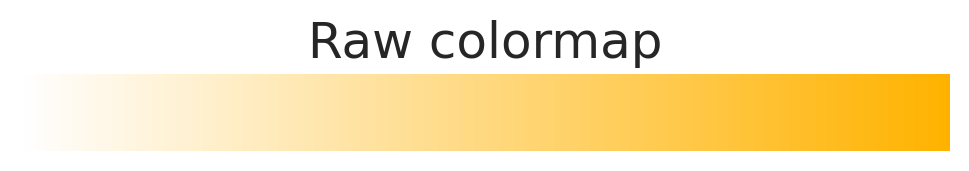

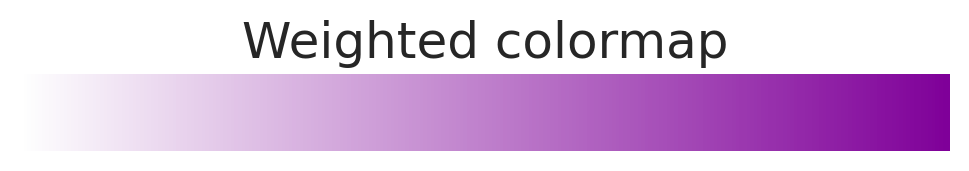

In [2]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "sans-serif",
        "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=True, **savefig_kwargs)


# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list("raw", [COL_WHITE, COL_RAW_RGB], N=256)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [ ]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("/home/galkepler/Projects/neuroaging/data")

# Output directory for figures
OUTPUT_DIR = Path("/home/galkepler/Projects/neuroaging/figures/fig4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [4]:
predictions_df = pd.read_csv("BAG_data.csv", index_col=0)
# predictions_df = predictions_df.filter(regex="BAG")

In [5]:
predictions_df.filter(regex="stacked").loc["CLMC10"]
# predictions_df.shape

stacked_age          26.370000
stacked_predicted    28.060104
stacked_BAG           1.690104
Name: CLMC10, dtype: float64

In [6]:
df_cov = pd.read_csv("~/Projects/plasticityhub/sessions.csv")
df_cov["subject_code"] = (
    df_cov["subject_code"]
    .astype(str)
    .str.replace("-", "")
    .str.replace(" ", "")
    .str.replace("_", "")
)
# df_cov = pd.read_csv("~/Projects/neuroaging/data/external/sessions.csv")
df_cov = df_cov.drop_duplicates(subset=["subject_code"]).set_index("subject_code")
# df_cov = pd.read_pickle(f"/media/storage/phd/papers/aging/{ATLAS}/gm_vol.pkl").reset_index(
#     drop=True
# )
# df_cov = pd.read_csv("~/Projects/plasticityhub/sessions.csv")
# df_cov = pd.read_csv("qV1v.csv")

# finished_subjects = (
#     pd.read_csv("/media/storage/phd/papers/aging/schaefer2018tian2020_400_7/subjects.csv")
#     .values.flatten()
#     .tolist()
# )
# df_cov = df_cov[df_cov["Subject Code"].isin(finished_subjects)]

# df_cov = df_cov.groupby("subject_code").first()
df = df_cov.merge(predictions_df, left_on="subject_code", right_index=True, how="outer")
df = df.dropna(subset="stacked_BAG")
# merge with cov
# df_cov = df_cov.merge(cov, left_on="subject_code", right_index=True, how="inner")
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)


# exercise_frequency_mapping = {
#     "פעמיים-שלוש בשבוע": 2.5,
#     "1-1": 1.5,
#     "יותר מ-3 פעמים בשבוע": 4,
# }
# df_cov["exercise_frequency"] = df_cov["exercise_frequency"].map(
#     exercise_frequency_mapping
# )
df.loc[df["filled"], "number_of_children"] = df.loc[df["filled"],"number_of_children"].fillna(0)

education_level_mapping = {
    "elementary school": 1,
    "partial high school": 2,
    "high_school": 3,
    "post-secondary": 4,
    "undergraduate": 5,
    "bachelor's degree": 6,
    "U": np.nan,
    # "other": np.nan,
}
df["education_level"] = df["education_level"].map(education_level_mapping)

for col in ["blood_sugar", "blood_pressure", "thyroids", "lipids"]:
    df[col] = (
        df[col]
        .str.lower()
        .map(
            {
                "high": 1,
                "normal": 0,
                "low": -1,
                "very low": -2,
                "very high": 2,
            }
        )
    )

In [7]:
from sklearn.preprocessing import MultiLabelBinarizer
a = df["nutrition"].str.replace("קטוגני/נמנע מפחמימות","Ketogenic").str.replace("Free from", "Ketogenic").str.replace(","," ").str.strip().fillna("Unknown")


ml = MultiLabelBinarizer()
nutrition_df = pd.DataFrame(ml.fit_transform(a.str.split()), columns=ml.classes_, index=a.index)
nutrition_df = nutrition_df.rename(columns=lambda x: x.replace(" ", "_").replace("-", "_"))
nutrition_df = nutrition_df.add_prefix("nutrition_")
df = df.join(nutrition_df).drop(columns=["nutrition"])

In [8]:
fs_output_template = (
    "/media/storage/yalab-dev/derivatives/freesurfer/sub-{subj}/stats/aseg_stats.csv"
)
for subject in df.index:
    fs_output = fs_output_template.format(subj=subject)
    if not Path(fs_output).exists():
        print(f"File {fs_output} does not exist, skipping subject {subject}")
        continue
    fs_df = pd.read_csv(fs_output, sep="\t")
    for col in fs_df.columns:
        df.loc[
            subject,
            col.lower()
            .replace("-", "_")
            .replace("3rd", "third")
            .replace("4th", "fourth")
            .replace("5th", "fifth"),
        ] = fs_df.loc[0, col]

In [9]:
df = df.replace("", pd.NA)  # Handle empty missing

In [10]:
# df.filter(regex="ventricle")
df["lateral_ventricles_mean"] = df.filter(regex="lateral_ventricle").mean(axis=1)
# df

In [11]:
fill_to_0 = [
    "weekly_workouts",
    "home_cooking_times_per_week",
    "number_of_children",
    "relationship_duration",
    "smoking",
    "cannabis",
]
for col in fill_to_0:
    df.loc[df["filled"],col] = df.loc[df["filled"], col].fillna(0)

In [12]:
mask = df["smoking"] == False & df["smoke_frequency_per_day"].isna()
df.loc[mask, "smoke_frequency_per_day"] = 0

mask = df["cannabis"] == False & df["canabis_frequency_per_week"].isna()
df.loc[mask, "canabis_frequency_per_week"] = 0

# df.loc[df["psychometric_score"] == 200, "psychometric_score"] = np.nan

In [13]:
import pandas as pd
from scipy.stats import spearmanr, ttest_ind, f_oneway, pointbiserialr
import statsmodels.api as OLS
from statsmodels.tools.tools import add_constant

features = [
    "psqi",
    "gad7",
    "phq9",
    "swls",
    "pcl5",
    "b5_extraversion",
    "b5_agreeableness",
    "b5_conscientiousness",
    "b5_emotional_stability",
    "b5_openness",
    "brain_health",
    "BMI",
    "weekly_workouts",
    "screen_time",
    "smartphone_usage",
    "home_cooking_times_per_week",
    "has_pet",
    "smoking",
    "cannabis",
    "alcohol",
    "caffeine",
    # "sugar_beverages",
    "water",
    # "nutrition",
    "marital_status",
    "number_of_children",
    "relationship_duration",
    "living_environment",
    "education_level",
    "psychometric_score",
    "lateral_ventricles_mean",
] + list(nutrition_df.columns)

target = "stacked_BAG"


In [14]:
missing_df = df[features + [target]].isna().mean().sort_values(ascending=False)
missing_df[missing_df > 0.2].head(20)
features = [f for f in features if f not in missing_df[missing_df > 0.2].index]

In [15]:
# # find participants who filled in the questionnaire
# df_filled = df[df["filled"]].copy()
# missing_df = df_filled[features + [target]].isna().mean().sort_values(ascending=False)
# missing_df[missing_df > 0.2].head(20)

df["nutrition_Unknown"].mean()

0.1882261812548412

In [16]:

# Impute missing
for col in features:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Convert binary to 0/1
binary_features = ["has_pet", "smoking", "cannabis"]  # Adjust based on your data
for col in binary_features:
    df[col] = df[col].map({True: 1, False: 0, "True": 1, "False": 0})  # Adjust mapping
    df[col] = df[col].fillna(df[col].mode()[0])  # Fill NaNs with mode

# Individual effects
results = []
for f in features:
    print(df[f].dtype, len(df[f].unique()))
    if df[f].dtype == "object" or len(df[f].unique()) < 5:  # Categorical or binary
        if len(df[f].unique()) == 2:  # Binary
            group0 = df[df[f] == df[f].unique()[0]][target]
            group1 = df[df[f] == df[f].unique()[1]][target]
            t, p = ttest_ind(group0, group1)
            d = (group1.mean() - group0.mean()) / group0.std() if group0.std() != 0 else 0
            results.append((f, "binary", d, p))
        else:  # Categorical
            groups = [df[df[f] == cat][target] for cat in df[f].unique()]
            f_val, p = f_oneway(*groups)
            eta2 = f_val * (len(groups) - 1) / (len(df) - len(groups) + f_val * (len(groups) - 1))
            results.append((f, "categorical", eta2, p))
    else:  # Continuous/ordinal
        r, p = spearmanr(df[f], df[target])
        results.append((f, "continuous", r, p))

float64 17
float64 34
float64 31
float64 34
float64 33
float64 36
float64 23
float64 1373
float64 13
float64 20
int64 2
int64 2
float64 17
float64 12
float64 25
object 8
float64 11
float64 94
object 10
float64 2582
int64 2
int64 2
int64 2
int64 2
int64 2
int64 2
int64 2
int64 2
int64 2
int64 2


In [17]:
print(pd.DataFrame(results, columns=["Feature", "Type", "Effect Size", "p-value"]).sort_values("p-value"))

                        Feature         Type  Effect Size       p-value
19      lateral_ventricles_mean   continuous     0.152104  7.821981e-15
13                     caffeine   continuous     0.085303  1.422654e-05
22              nutrition_Other       binary    -1.377877  5.958564e-03
27            nutrition_Unknown       binary     0.123555  1.430963e-02
8               weekly_workouts   continuous     0.043519  2.701319e-02
15               marital_status  categorical     0.005864  3.408771e-02
17        relationship_duration   continuous    -0.038315  5.157155e-02
10                      smoking       binary     0.118165  6.740037e-02
2              b5_agreeableness   continuous     0.034264  8.173090e-02
28              nutrition_Vegan       binary    -0.170993  8.494024e-02
16           number_of_children   continuous    -0.033698  8.690738e-02
9   home_cooking_times_per_week   continuous     0.033001  9.362889e-02
18           living_environment  categorical     0.005508  1.145

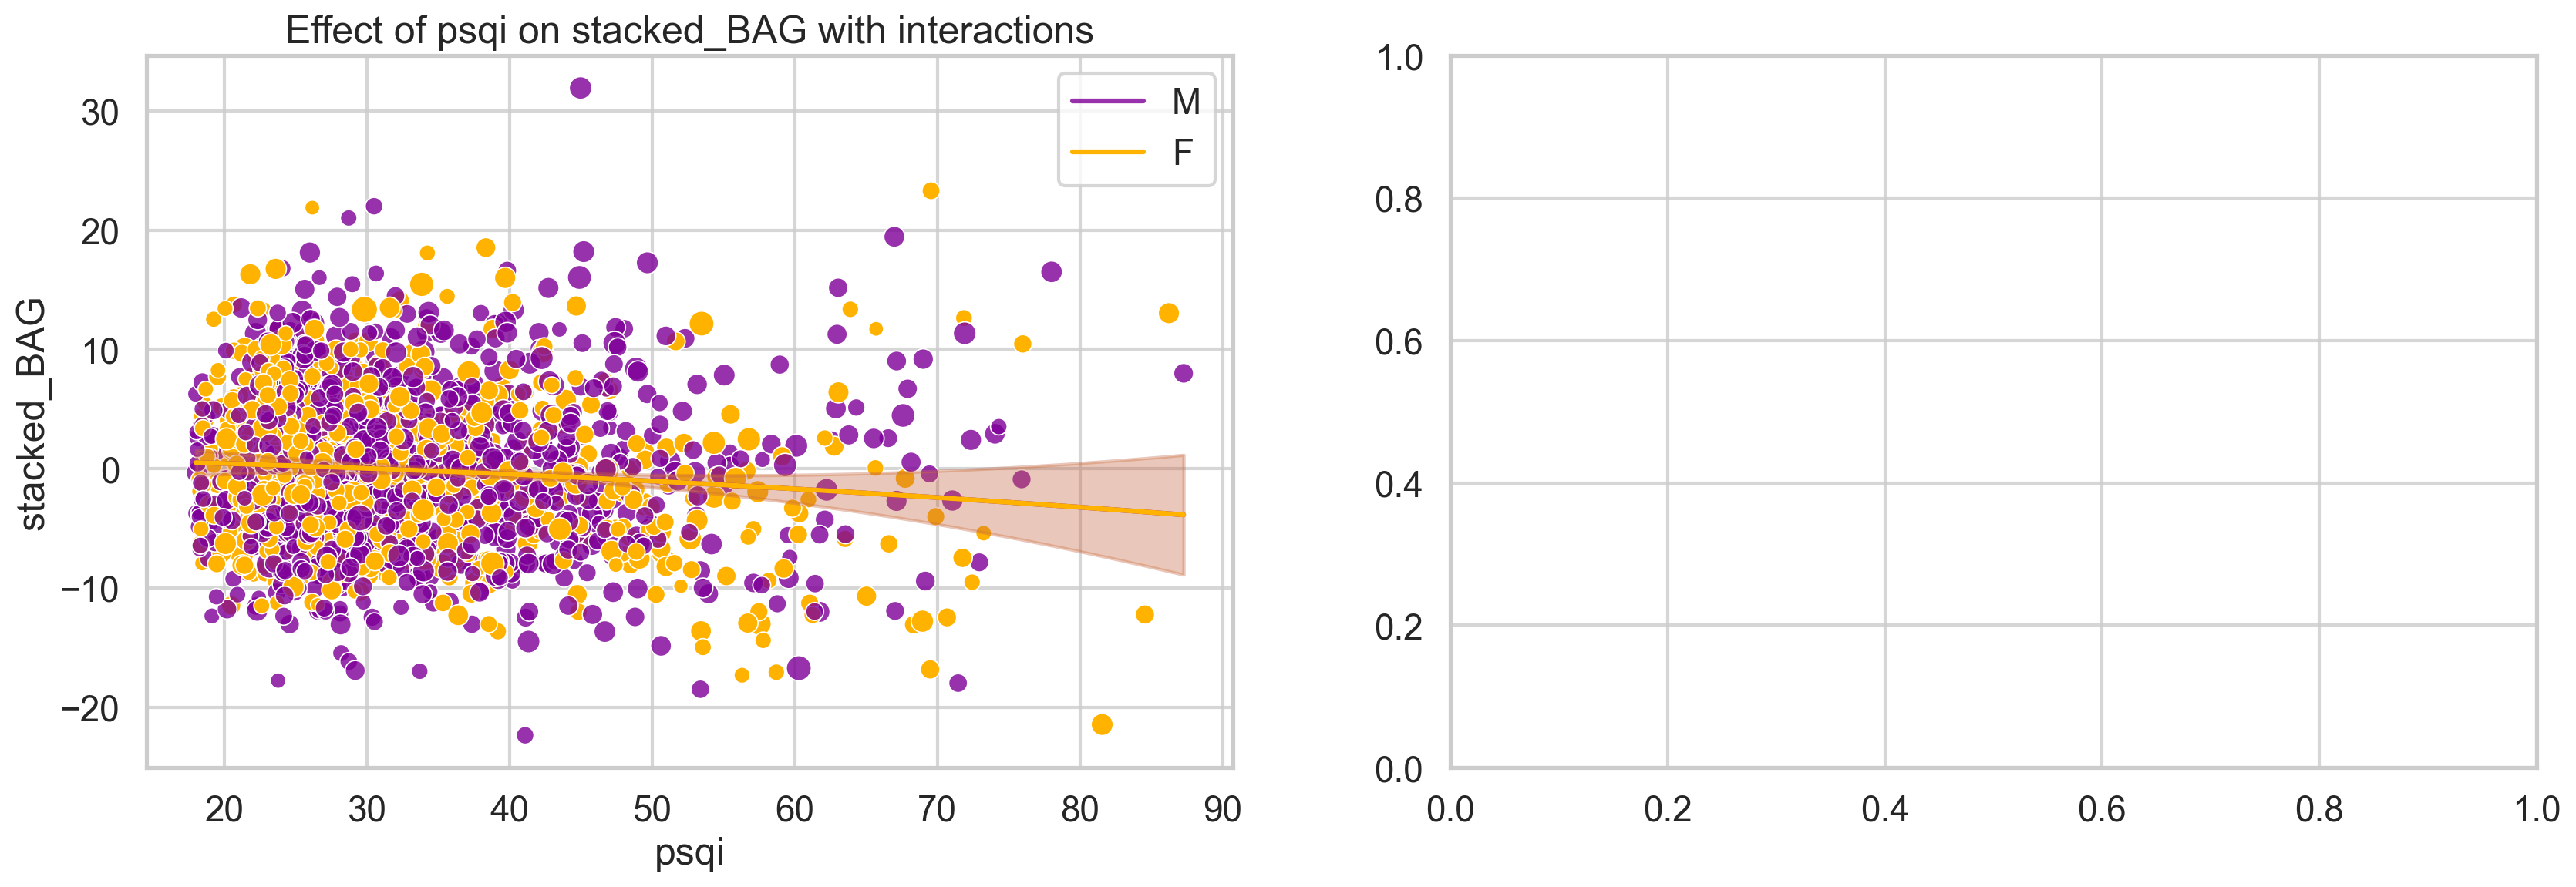

In [18]:
from statsmodels.formula.api import ols
# plot (x axis is feature, y axis is target, size is age, color is sex)
features_of_interest = ["lateral_ventricles_mean", "BMI", "caffeine", "alcohol", "psqi"]
feature = "psqi"

# Fit a linear model with OLS (include interactions)
# for feature in features_of_interest:
formula = f"{target} ~ {feature} * age_at_scan"
model = ols(formula, data=df)
results = model.fit()
# print(results.summary())
# break
fig, axes = plt.subplots(1,2,figsize=(20, 6))
ax = axes[0]
sns.scatterplot(
    data=df,
    x="age_at_scan",
    y= target,
    size="BMI",
    hue="sex",
    ax=ax,
    palette={"M": COL_WEIGHTED, "F": COL_RAW},
)
# add regression line
# simulate data for predictions
lines = []
labels = []
for s in ["M","F"]:
    pred_df = pd.DataFrame(
        {"age_at_scan": np.linspace(df["age_at_scan"].min(), df["age_at_scan"].max(), 100),
        feature: np.linspace(df[feature].min(), df[feature].max(), 100),
        "sex": s}
    )
    predictions = results.get_prediction(pred_df)
    predictions = predictions.summary_frame(alpha=0.05)
    # plot the regression line
    lines+=ax.plot(pred_df["age_at_scan"], predictions["mean"], color=COL_WEIGHTED if s == "M" else COL_RAW)
    labels.append(s)
    ax.fill_between(
        pred_df["age_at_scan"],
        predictions["mean_ci_lower"],
        predictions["mean_ci_upper"],
        color=COL_WEIGHTED if s == "M" else COL_RAW,
        alpha=0.2,
        label="95% CI"
    )
ax.set_title(f"Effect of {feature} on {target} with interactions")
ax.set_xlabel(feature)
ax.set_ylabel(target)
ax.legend(lines, labels)

# # split age to bins, fit a linear model for each bin
# bins = np.linspace(df["age_at_scan"].min(), df["age_at_scan"].max(), 100)
# df["age_bin"] = pd.cut(df["age_at_scan"], bins=bins)
# # fit a linear model for each bin
# results = []
# for age_bin in df["age_bin"].unique():
#     bin_df = df[df["age_bin"] == age_bin]
#     mean_age = bin_df["age_at_scan"].mean()
#     median_age = bin_df["age_at_scan"].median()
#     n_age = len(bin_df)
#     if len(bin_df) < 10:  # skip bins with too few data points
#         continue
#     model = ols(f"{target} ~ {feature} * age_at_scan", data=bin_df).fit()
#     results.append((age_bin, model.params[feature], model.tvalues[feature], model.pvalues[feature], mean_age, median_age, n_age))
# results_df = pd.DataFrame(results, columns=["age_bin", "effect_size", "t_value", "p_value", "mean_age", "median_age", "n_age"])
# results_df["p-value < 0.05"] = results_df["p_value"] < 0.05
# # fit a linear model for the results
# model = ols("t_value ~ median_age + I(median_age ** 2)", data=results_df).fit()
# # plot the results
# ax = axes[1]
# sns.scatterplot(

#     data=results_df,
#     x="median_age",
#     y="t_value",
#     size="n_age",
#     hue="p-value < 0.05",
#     palette={True: COL_WEIGHTED, False: COL_RAW},
#     ax=ax,
# )
# # add regression line
# pred_df = pd.DataFrame(
#     {"median_age": np.linspace(results_df["median_age"].min(), results_df["median_age"].max(), 100)}
# )
# predictions = model.get_prediction(pred_df)
# predictions = predictions.summary_frame(alpha=0.05)
# # plot the regression line
# lines = ax.plot(pred_df["median_age"], predictions["mean"], color=COL_WEIGHTED)
# ax.fill_between(
#     pred_df["median_age"],
#     predictions["mean_ci_lower"],
#     predictions["mean_ci_upper"],
#     color=COL_WEIGHTED,
#     alpha=0.2,
#     label="95% CI",
# )
# ax.set_title(f"Effect of {feature} on {target} by age bin")
# ax.set_xlabel("Median Age")
# ax.set_ylabel("Effect Size")
# ax.legend(lines, [f"Effect Size ~ median_age - $R^2$ = {model.rsquared:.2f}, p = {model.f_pvalue:.3f}"])
# # ax.legend(lines, ["Effect Size"])


In [19]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
# plot (x axis is feature, y axis is target, size is age, color is sex)
features_of_interest = ["lateral_ventricles_mean", "BMI", "caffeine", "alcohol", "psqi"]


# split age to sliding windows

def rolling_window_analysis(df, x_col='BMI', target=target, group_size=50, step=10, fit_quadratic=True):
    """
    Perform rolling window analysis on sorted age data.
    
    Sorts df by age ascending, then slides overlapping windows of size group_size with step.
    For each window, fits OLS: target ~ age_at_scan + x_col, extracts beta/p for x_col.
    Returns DF with results and fits beta ~ median_age.
    
    Parameters:
    - df: DataFrame with 'age', 'age_at_scan', target, x_col.
    - x_col: Predictor column (e.g., 'BMI').
    - target: Dependent variable (e.g., 'residuals').
    - group_size: Window size (default 50).
    - step: Step for overlapping windows (default 10; smaller = more overlap).
    
    Returns:
    - bins_df: DataFrame with per-window stats.
    - model_summary: Summary of beta ~ median_age OLS.
    """
    # Filter NaN in x_col and sort by age ascending
    df_test = df[df[x_col].notna()].copy()
    df_test = df_test.sort_values("age_at_scan", ascending=True).reset_index(drop=True)

    # Initialize results DF
    bins_df = pd.DataFrame(columns=["median_age", "group_size", "min_age", "max_age", f"{target}_median", 
                                f"{x_col}_beta", f"{x_col}_p", "r2", "r2_adj", "p"]) 

    # Rolling windows loop
    for i in range(0, len(df_test) - group_size + 1, step):
        group = df_test.iloc[i:i + group_size]
        age = group["age_at_scan"].median()

        row_idx = len(bins_df)
        bins_df.loc[row_idx, "median_age"] = age
        bins_df.loc[row_idx, "group_size"] = len(group)
        bins_df.loc[row_idx, "min_age"] = group["age_at_scan"].min()
        bins_df.loc[row_idx, "max_age"] = group["age_at_scan"].max()
        bins_df.loc[row_idx, f"{target}_median"] = group[target].median()
        
        # OLS: target ~ age_at_scan + x_col
        formula = f"{target} ~ age_at_scan + {x_col}"
        # if fit_quadratic:
        #     formula += " + I(age_at_scan ** 2)"
        # formula = f"{target} ~ {x_col}"
        res = ols(formula, data=group).fit()
        bins_df.loc[row_idx, f"{x_col}_beta"] = res.params[x_col]
        bins_df.loc[row_idx, f"{x_col}_p"] = res.pvalues[x_col]
        bins_df.loc[row_idx, "r2"] = res.rsquared
        bins_df.loc[row_idx, "r2_adj"] = res.rsquared_adj
        bins_df.loc[row_idx, "p"] = res.f_pvalue  # p-value of the overall model

        

    # Correlation between beta and median_age
    formula = f"{x_col}_beta ~ median_age"
    if fit_quadratic:
        formula += " + I(median_age ** 2)"
    model = ols(formula, data=bins_df.astype(float)).fit()

    return bins_df.astype(float), model


# fit_quadratic = False
# bins_df, model = rolling_window_analysis(df, x_col=feature, target=target, fit_quadratic=False)

In [28]:
feature = "caffeine"
bins_df, mod_lin = rolling_window_analysis(df, x_col=feature, target=target, fit_quadratic=False)
_, mod_quad = rolling_window_analysis(df, x_col=feature, target=target, fit_quadratic=True)

In [29]:
mod_quad.compare_f_test(mod_lin)

(12.805023764163586, 0.00041479442187859067, 1.0)

In [30]:
features_vis = {
    "BMI": "BMI",
    "lateral_ventricles_mean": "Lat. Vent. Volume",
    "caffeine": "Caffeine Intake",
    "alcohol": "Alcohol Intake",
    "psqi": "PSQI Score",
}

Text(0, 0.5, '$\\beta_{Caffeine Intake}$')

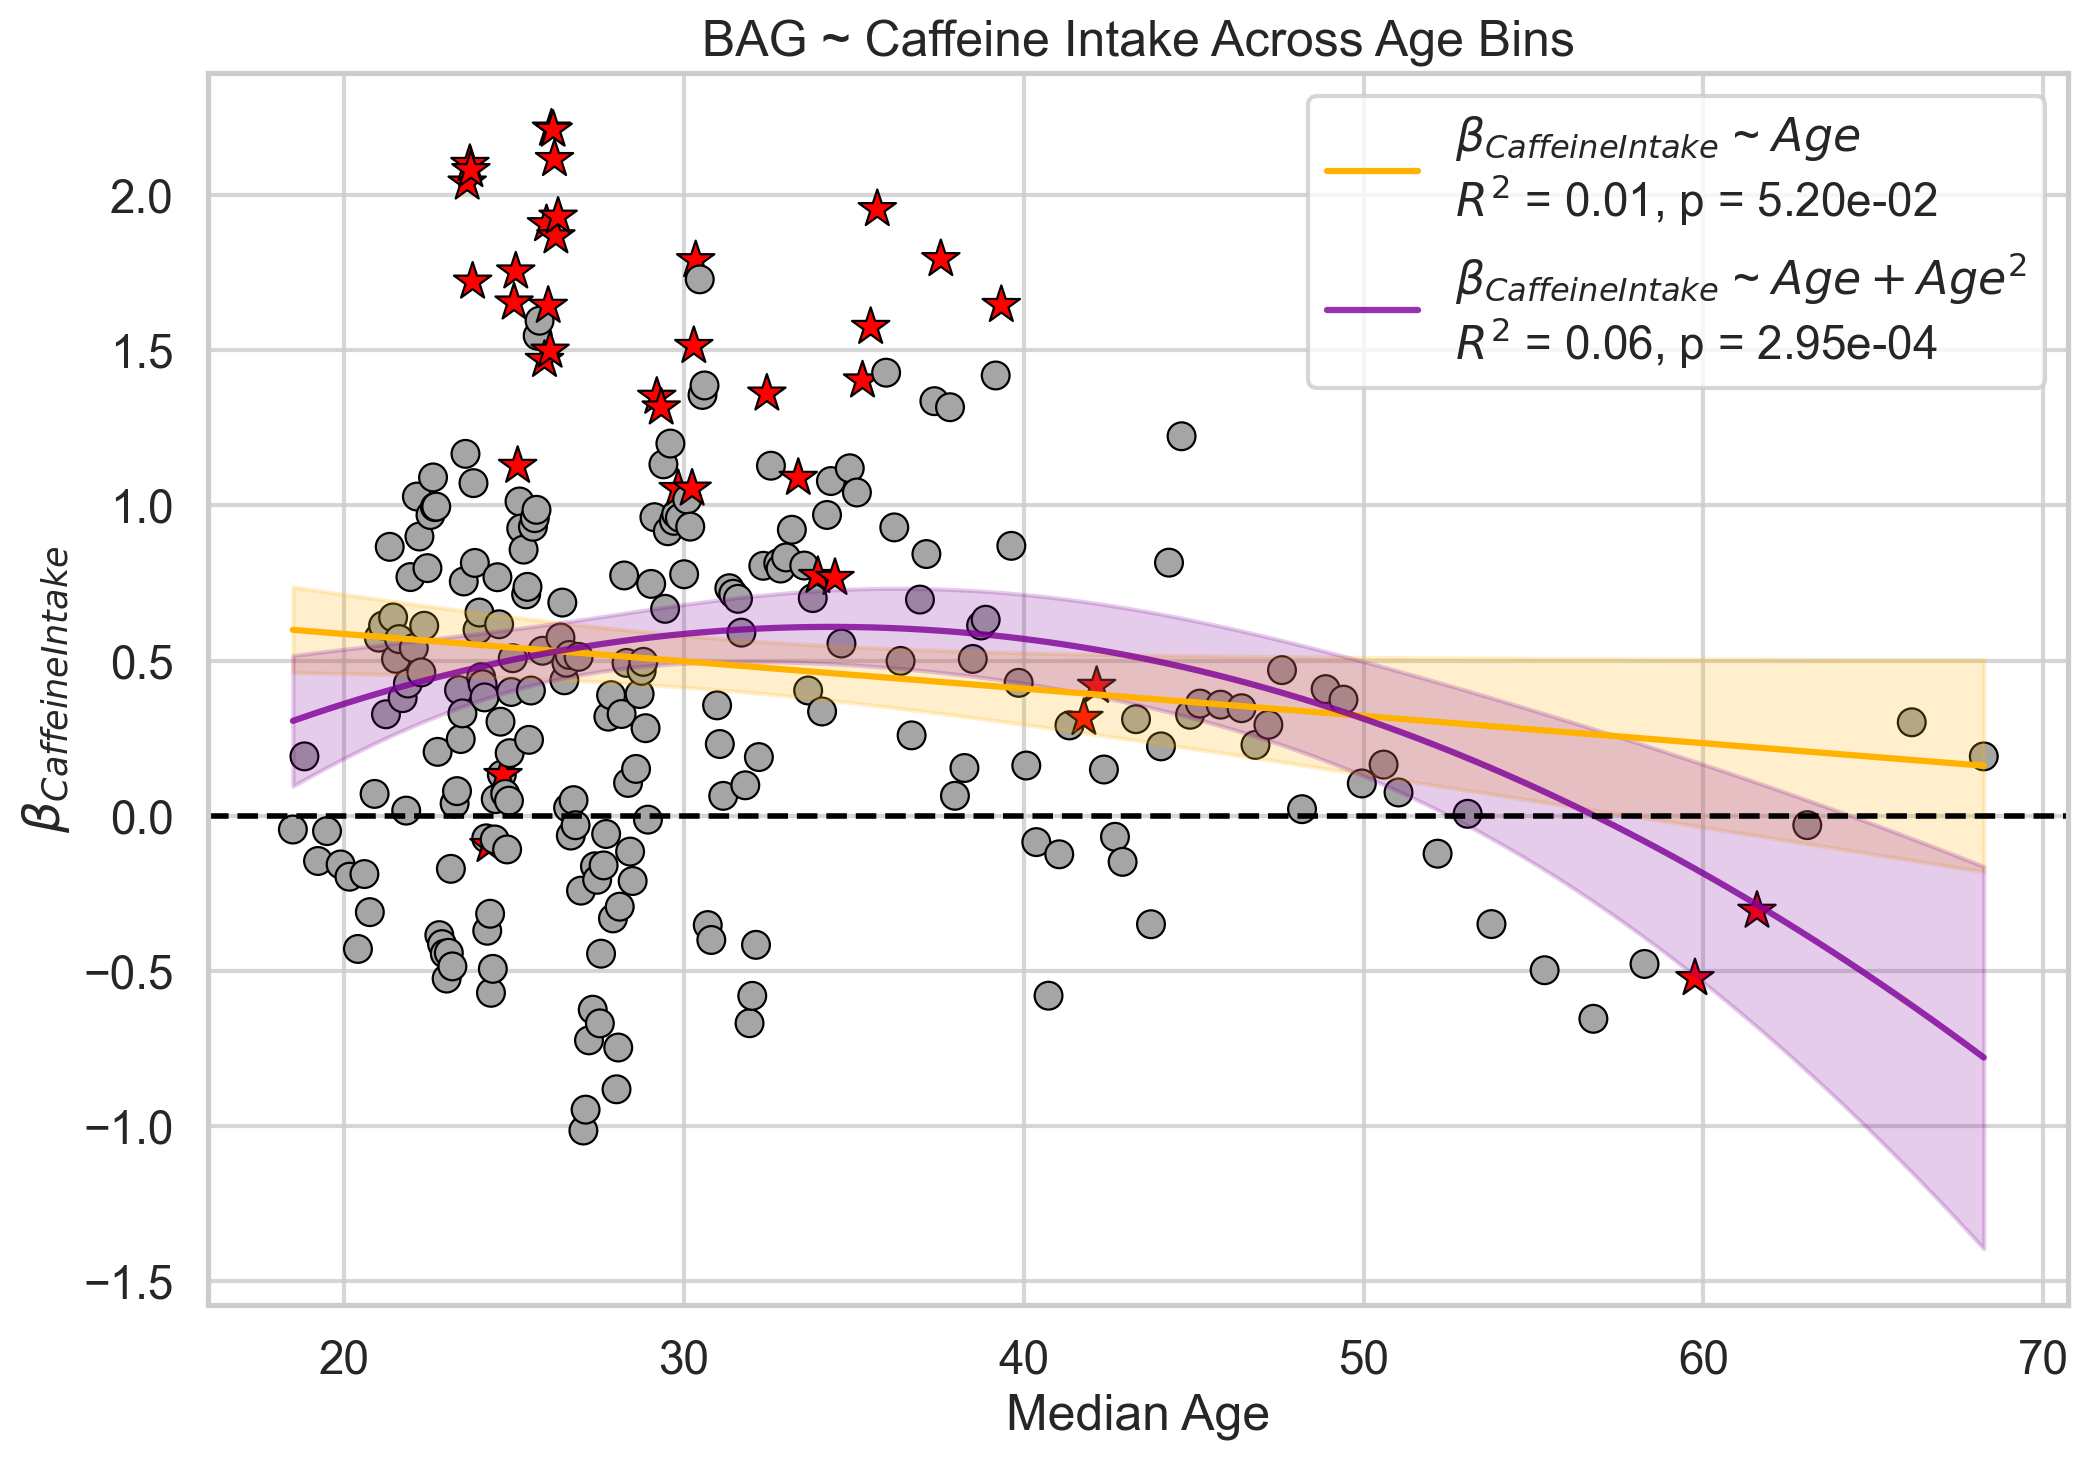

In [31]:
bins_df["p < 0.05"] = bins_df["p"] < 0.05
bins_df["size"] = bins_df["p < 0.05"].map({True: 100, False: 50}).astype(float)
# plot
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=bins_df,
    x="median_age",
    y=f"{feature}_beta",
    # make p<0.05 star markers
    style="p < 0.05",
    markers={True: "*", False: "o"},
    # make p<0.05 larger
    size="size",
    sizes=(100, 200),
    # make start markers red and o markers blue
    hue="p < 0.05",
    palette={True: "red", False: COL_CENSUS},
    edgecolor="black",
    ax=ax,
)
# add regression lines
pred_df = pd.DataFrame(
    {"median_age": np.linspace(bins_df["median_age"].min(), bins_df["median_age"].max(), 100)}
)
lines = []
labels = []
for model, col, is_quadratic in zip([mod_lin, mod_quad], [COL_RAW, COL_WEIGHTED], [False,True]):
    # simulate data for predictions
    predictions = model.get_prediction(pred_df)
    predictions = predictions.summary_frame(alpha=0.05)
    # plot the regression line
    lines += ax.plot(pred_df["median_age"], predictions["mean"], color=col)
    ax.fill_between(
        pred_df["median_age"],
        predictions["mean_ci_lower"],
        predictions["mean_ci_upper"],
        color=col,
        alpha=0.2,
        label="95% CI",
    )
    if is_quadratic:
        label = f"$\\beta_{{{features_vis[feature]}}}$ ~ $Age + Age^2$\n$R^2$ = {model.rsquared:.2f}, p = {model.f_pvalue:.2e}"
    else:
        label = f"$\\beta_{{{features_vis[feature]}}}$ ~ $Age$\n$R^2$ = {model.rsquared:.2f}, p = {model.f_pvalue:.2e}"
    labels += [label]

ax.axhline(0, color="black", linestyle="--", linewidth=2)
ax.legend(lines, labels)

ax.set_title(f"BAG ~ {features_vis[feature]} Across Age Bins")
ax.set_xlabel("Median Age")
ax.set_ylabel(f"$\\beta_{{{features_vis[feature]}}}$")
